This notebook runs through elements of the optimized first wedge and the QQ+Sector Dipole dispersion suppressor.

Written by: Inci Karaaslan

Created: 2/22/2026

# Setup

In [1]:
# Important! All of the functions utilized in this notebook unless defined here comes from these two scripts. 
# For more information on the functions, check scan.py and g4beam.py!!
from scan import *
from g4beam import *
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
from tabulate import tabulate
import re

In [2]:
# Make Sure g4bl path is in here -- change the "/home/incik/G4beamline-3.08/bin" with your "G4beamline-3.08/bin" path
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


# Initial distribution

First Wedge Optimization done by Daniel Fu: A Gaussian beam is generated using Mike Syphers' theoretical description of the parameters needed via https://nicadd.niu.edu/~syphers/tutorials/analyzeTrack.html#analyzing-a-distribution.

The parameters of the initial beam are treated as constants, but some things are known about their effects:
- **Transverse emittance**: Should be as low as possible. For this test we use an "optimistic" value of 110 microns.
- **Momentum**: Decreasing this appears to slightly decreases x-emittance.
- **Beta**: Decreasing this decreases the y-emittance growth. There may also be an optimal value for x-emittance.
- **Alpha**: Increasing this decreases the y-emittance growth, but past a certain point increases the x-emittance. I believe 0.7 focuses the beam onto the wedge center with a VD distance of 24 mm.
- **Longitudinal emittance**: Effects not yet tested.
- **Standard deviation of momentum**: Decreasing this decreases the x-emittance.
- **Virtual detector distance**: Almost irrelevant. Should be more than 3x the length of the wedge to ensure accurate measurements.

In [3]:
t_emit = 0.145  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 0.7     # dimensionless
l_emit = 1      # mm
pz_std = 1    # MeV/c
vd_dist = 24    # mm

pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
pre_w1["PDGid"] = -13
print_all_params(pre_w1)

-----------------------------
Twiss parameters for X
emit  = 0.14688640465939473 mm
beta  = 0.03002459530770521 m
gamma = 49.495664955494156 1/m
alpha = 0.697199619746367
D     = 0.0005299052207820417 m
D'    = 0.06216470901586414

Twiss parameters for Y
emit  = 0.14567059177256192 mm
beta  = 0.03014575446100707 m
gamma = 49.62640636364279 1/m
alpha = 0.7042907503442981
D     = 0.0014236517747372994 m
D'    = -0.08171808059574054

Z-emittance:  1.267399101227275 mm
Z std: 154.4915545435066 mm
p std: 1.0026427767145911 MeV/c
Mean momentum: 99.99253150026742 MeV/c
-----------------------------


In [4]:
write_trackfile(pre_w1, "particles_before_firstwedge.txt")

# First wedge -- Run Optimized Value

In [6]:
post_w1 =  run_g4beam(pre_w1, "G4_FinalCooling_auto.g4bl")
print_all_params(post_w1)

-----------------------------
Twiss parameters for X
emit  = 0.04407814533049926 mm
beta  = 0.0355271946503599 m
gamma = 199.64703262232567 1/m
alpha = -2.468379830848591
D     = 0.020065444404110476 m
D'    = -0.03990290701206469

Twiss parameters for Y
emit  = 0.15222162966227434 mm
beta  = 0.02552653111069988 m
gamma = 57.448864294406306 1/m
alpha = -0.6829862529257366
D     = 0.00023537262451525805 m
D'    = 0.02864526183078483

Z-emittance:  6.439225382449198 mm
Z std: 142.83664804505435 mm
p std: 7.240070098325844 MeV/c
Mean momentum: 87.96471090397651 MeV/c
-----------------------------


In [7]:
# Write the wedge output into a file
write_trackfile(post_w1, "particles_after_firstwedge.txt")

In [8]:
# Optimized G4_FinalCooling_auto.g4bl parameters
w1_length = 7.08 #mm
w1_angle = 47.2 #deg
offset = w1_length / (math.tan(w1_angle * math.pi / 180) * 2)
base_length = 24
abswidth = 100
parameters = dict(
        abshalfangle3=str(w1_angle),
        absoffset3=str(offset),
        abshgt=str(offset * base_length / w1_length + 0.1),
        absLEN3=str(base_length)
    )
L_centerline = float(parameters['absLEN3']) + 1
print("Where to put the next element: " + str(L_centerline) + "mm")

Where to put the next element: 25.0mm


In [9]:
# If particles_after isn't updated with Z = 0, so if we want to use the resulting distribution as the initial distribution
# for each of the files, we must set the particle distribution we get after to have a z of 0.
def convertZ(input_file, output_file, set_to=0):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = str(set_to)  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None

In [10]:
convertZ("particles_after_firstwedge.txt", "particles_after_firstwedgeupt.txt", set_to=0.0)

Updated file saved as 'particles_after_firstwedgeupt.txt'


# Dispersion correction optimized

The main goal is to have $D_x \approx 0$ up to 1e-5 m while keeping $\beta_x$ relatively periodic and about at the same value.

In [11]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, replacements, out_path):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

In [12]:
def clean_field_files():
    for f in ["field_cellBSec.dat", "field_cellQ2.dat"]:
        if os.path.exists(f):
            os.remove(f)

In [45]:
# Beta and Dispersion we have from after the wedge:
x0_params, y0_params, _ = calc_all_params(post_w1)
beta_x_ref= x0_params[1]; beta_y_ref= y0_params[1]
print(r"$\beta_x$: " + str(beta_x_ref), r"$\beta_y$: " + str(beta_y_ref))
print("D_x: " + str(x0_params[4]), "D_y: " + str(y0_params[4]))
print("Emittance: " + str(x0_params[0]))

$\beta_x$: 0.04297079429806787 $\beta_y$: 0.025456540294935555
D_x: 0.020673913232967234 D_y: 0.00019678394564673346
Emittance: 0.03310116919462851


In [46]:
print_all_params(post_w1)

-----------------------------
Twiss parameters for X
emit  = 0.03310116919462851 mm
beta  = 0.04297079429806787 m
gamma = 243.10964953470935 1/m
alpha = -3.0735345682180584
D     = 0.020673913232967234 m
D'    = -0.061719690478807744

Twiss parameters for Y
emit  = 0.14774402574098636 mm
beta  = 0.025456540294935555 m
gamma = 56.097496255214864 1/m
alpha = -0.6542539062671874
D     = 0.00019678394564673346 m
D'    = 0.004272551008148743

Z-emittance:  3.6873793774832166 mm
Z std: 143.04438939572938 mm
p std: 4.237280062756874 MeV/c
Mean momentum: 88.41040676840015 MeV/c
-----------------------------


In [73]:
write_trackfile(post_w1, "particles_after_firstwedge.txt")

In [154]:
def beam_size(beta, eps, n_sigma=15):
    """
    Compute full beam width/height in mm for given beta (m) and emittance (mm·mrad)
    """
    sigma = np.sqrt(beta * eps * 1e3)  # convert sigma (mm) = sqrt(m * 1e3 * mm)
    return n_sigma * sigma

n_sigma_x = beam_size(x0_params[1], x0_params[0])
n_sigma_y = beam_size(y0_params[1], y0_params[0])
print("Determine the Quad Width: " + str(n_sigma_x),"Determine the Quad Height: " + str(n_sigma_y))
radius_q = max(n_sigma_x, n_sigma_y)
print("So the quad radius: " + str(radius_q) + " mm")
B_pole_max = 5.0
gradBound = B_pole_max / (radius_q*1e-3)
print(f"Max gradient bound for quads : ({-gradBound}, {gradBound}) ")

Determine the Quad Width: 17.889558262008105 Determine the Quad Height: 29.090146829082325
So the quad radius: 29.090146829082325 mm
Max gradient bound for quads : (-171.8795037157167, 171.8795037157167) 


In [85]:
# Actual max displacement in x including all dispersive tails
x_max = np.percentile(np.abs(post_w1["x"]), 99)  # 99th percentile to ignore outliers
y_max = np.percentile(np.abs(post_w1["y"]), 99)

radius_q = max(x_max, y_max) * 1.5  # 50% margin on top of actual beam extent
print(f"x_max={x_max:.1f} mm, y_max={y_max:.1f} mm, radius_q={radius_q:.1f} mm")

x_max=4.2 mm, y_max=5.5 mm, radius_q=8.3 mm


In [ ]:
# Radius of the quads should be:
radius_q = max(
    np.percentile(np.abs(post_w1["x"]), 99.9),
    np.percentile(np.abs(post_w1["y"]), 99.9)
    ) * 10.0
print("So the second quad radius: " + str(radius_q) + " mm")

So the second quad radius: 69.69639960000002 mm


In [95]:
def run_two_quadrupoles(df, Q1_gradient, Q2_gradient, Drift1_length, Q1_z, Q1_radius=radius_q, Q2_radius=radius_q, Q1_length=100, Q2_length=100, thickness=5):
    """
    Runs G4BL with two sequential quadrupoles.
    """
    Drift1_width=2*max(Q1_radius,Q2_radius)
    Drift1_height=2*max(Q1_radius,Q2_radius)
    # Q1_z : f"{L_centerline + (Q1_length / 2):.12f}",
    params = {
    "Q1_z": f"{Q1_z + (Q1_length / 2):.12f}",
    "Q1_length": f"{Q1_length:.12f}",
    "Q1_gradient": f"{Q1_gradient:.12f}",
    "radius_q1": f"{Q1_radius:.12f}",
    "radius_q2": f"{Q2_radius:.12f}",
    "thickness": f"{thickness:.12f}",
    "Q1_end": f"{Q1_z + Q1_length:.12f}",
    "Q2_length":f"{Q2_length:.12f}",
    "Q2_gradient": f"{Q2_gradient:.12f}",
    "Drift1_length": f"{Drift1_length:.12f}",
    "Drift1_z": f"{Q1_z + Q1_length + (Drift1_length / 2):.12f}",
    "Drift1_width": f"{Drift1_width:.12f}", 
    "Drift1_height":f"{Drift1_height:.12f}",
    "D1_end": f"{Q1_z + Q1_length + Drift1_length:.12f}",
    "Q2_z": f"{Q1_z + Q1_length + Drift1_length + Q2_length/2:.12f}",
    "Q2_end": f"{Q1_z + Q1_length + Drift1_length + Q2_length:.12f}",
    }

    print("PARAMS PASSED TO TEMPLATE:")
    for k, v in params.items():
        print(k, "=", v)
    write_input_from_template("G4_FinalCooling_dispsup_Q2.g4bl", params, "G4_FinalCooling_dispsup_Q2_run.g4bl")
    
    # Run this file
    res = run_g4beam(df, "G4_FinalCooling_dispsup_Q2_run.g4bl")

    if res is None or len(res) < 10:
        print("G4BL run failed or empty. Check template and parameters.")
        return None
    return res

In [117]:
history = []
def optimize_qq_drift_safe(x, df, beta_x_ref, beta_y_ref, w_disp=1000, w_beta=10000.0):
    """
    Optimizer wrapper with:
    - Survival-aware penalty
    - Full diagnostics
    """

    q1_gradient, q2_gradient, d1_length, q1_z = x
    print("\nTRYING x =", x)

    try:
        result = run_two_quadrupoles(df, q1_gradient, q2_gradient, d1_length, q1_z)
        # Check where particles are dying
        print(f"x range: {result['x'].min():.1f} to {result['x'].max():.1f} mm")
        print(f"y range: {result['y'].min():.1f} to {result['y'].max():.1f} mm")
        print(f"Pz range: {result['Pz'].min():.1f} to {result['Pz'].max():.1f} MeV/c")
        print(f"Input: {2000}, Output: {len(result)}")
    except Exception as e:
        print("EXCEPTION in run_two_quadrupoles:", e)
        return 1e6

    if result is None or len(result) == 0:
        print("No particles survived")
        return 1e6

    # Compute survival fraction
    N0 = 2000 #len(df)
    Ns = len(result)

    survival = Ns / N0
    print(f"Particles survived: {Ns}/{N0} → survival={survival:.3f}")

    if survival < 0.95:
        print(f"Survival too low, returning penalty")
        return 1e7 + 1e6 * (0.95 - survival)

    # Compute optics parameters
    try:
        x_params, y_params, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5
    

    Dx = x_params[4]
    Dxp = x_params[5]
    beta_x = x_params[1]
    beta_y = y_params[1]
    ex = x_params[0]
    ey = y_params[0]
    
    eps = 1e-4
    
    disp_penalty =  (np.abs(Dx) / 1e-4)**2 + (np.abs(Dxp) / 1e-2)**2
    beta_penalty = ((beta_x - beta_x_ref) / beta_x_ref)**2 + ((beta_y - beta_y_ref) / beta_y_ref)**2
    # Log-scaled optics loss
    optics_loss = w_beta * np.log(beta_penalty**2 + eps)
    disp_loss = w_disp * np.log(disp_penalty + eps)

    # Total objective
    val = optics_loss + disp_loss

    print(f"OBJECTIVE = {val:.6f}, Dx={Dx:.6f}, Dxp={Dxp:.6f}, beta_penalty={beta_penalty:.6f}, emit={ex:.6f}")
    history.append({
    "Q1_G": q1_gradient,
    "Q2_G": q2_gradient,
    "Drift1_L": d1_length,
    "Q1_z": q1_z,
    "Dx": Dx,
    "beta_x": beta_x,
    "beta_y": beta_y,
    "survival": survival,
    "objective": val})
    return val

In [119]:
"""from skopt import gp_minimize"""
x0 = [-61.97363495,  69.06470063,   2.02317333,  25.        ]# [ -9.00758863, 11.56562394, 19.697143, L_centerline*2] #[-9.00758863, 11.56562394,  40.41906277, L_centerline] # [ -9.00758863, 11.56562394, 19.697143, L_centerline]
# [-61.97363495  69.06470063   2.02317333  25.        ] BEST transmission
# Physical bounds
bounds = np.array([
    [-gradBound, gradBound],      # Q1_gradient
    [-gradBound, gradBound],    # Q2_gradient
    [1, 3000],    # Drift1_length
    [L_centerline, L_centerline*100]
])

res = scipy.optimize.minimize(
    optimize_qq_drift_safe, x0,
    args=(post_w1, beta_x_ref, beta_y_ref),
    method="Nelder-Mead", bounds=bounds,
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500}
)
"""res = gp_minimize(
    lambda x: optimize_qq_drift_safe(x, post_w1, beta_x_ref, beta_y_ref),
    bounds,
    x0=[x0],   # your initial guess here (must be a list of lists)
    n_calls=50,
    n_initial_points=10,
    random_state=42)"""
print("Optimal parameters:", res.x)


TRYING x = [-61.97363495  69.06470063   2.02317333  25.        ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000000000000
Q1_length = 100.000000000000
Q1_gradient = -61.973634950000
radius_q1 = 69.696399600000
radius_q2 = 69.696399600000
thickness = 5.000000000000
Q1_end = 125.000000000000
Q2_length = 100.000000000000
Q2_gradient = 69.064700630000
Drift1_length = 2.023173330000
Drift1_z = 126.011586665000
Drift1_width = 139.392799200000
Drift1_height = 139.392799200000
D1_end = 127.023173330000
Q2_z = 177.023173330000
Q2_end = 227.023173330000
x range: -44.6 to 44.1 mm
y range: -42.6 to 41.6 mm
Pz range: 40.0 to 95.1 MeV/c
Input: 2000, Output: 1902
Particles survived: 1902/2000 → survival=0.951
OBJECTIVE = 153861.095925, Dx=0.041432, Dxp=-0.779698, beta_penalty=951.835460, emit=0.699335

TRYING x = [-65.0723167   69.06470063   2.02317333  25.        ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000000000000
Q1_length = 100.000000000000
Q1_gradient = -65.072316697500
radius_q1 = 69.696399600000
radi

In [120]:
df_opt_q = run_two_quadrupoles(post_w1, Q1_gradient=res.x[0], Q2_gradient=res.x[1], Drift1_length=res.x[2], Q1_z=res.x[3])
print(df_opt_q)
write_trackfile(df_opt_q, "particles_after_q2.txt")

PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000006120512
Q1_length = 100.000000000000
Q1_gradient = -62.894274814131
radius_q1 = 69.696399600000
radius_q2 = 69.696399600000
thickness = 5.000000000000
Q1_end = 125.000006120512
Q2_length = 100.000000000000
Q2_gradient = 70.671819523598
Drift1_length = 2.000924589217
Drift1_z = 126.000468415121
Drift1_width = 139.392799200000
Drift1_height = 139.392799200000
D1_end = 127.000930709729
Q2_z = 177.000930709729
Q2_end = 227.000930709729
              x         y        z         Px        Py       Pz         t  \
0     -5.584740 -10.74900  227.001   9.208870 -12.17050  79.9833  0.357575   
1     30.410100 -26.84610  227.001 -46.548400 -27.17190  71.1902  0.390722   
2    -39.983000 -23.03490  227.001  66.521800 -24.03160  57.3336  1.881010   
3      6.645150  17.12300  227.001  -9.208240  19.94960  82.2514  0.604313   
4     32.432400 -16.56740  227.001 -65.806800 -17.49050  46.5820  0.449078   
...         ...       ...      ...        ...       ..

Chromaticity proxy (slope of beta vs delta):
dβx/dδ ≈ 6.2423
dβy/dδ ≈ 2.6320
Quadratic term βx: 8.419935417107434


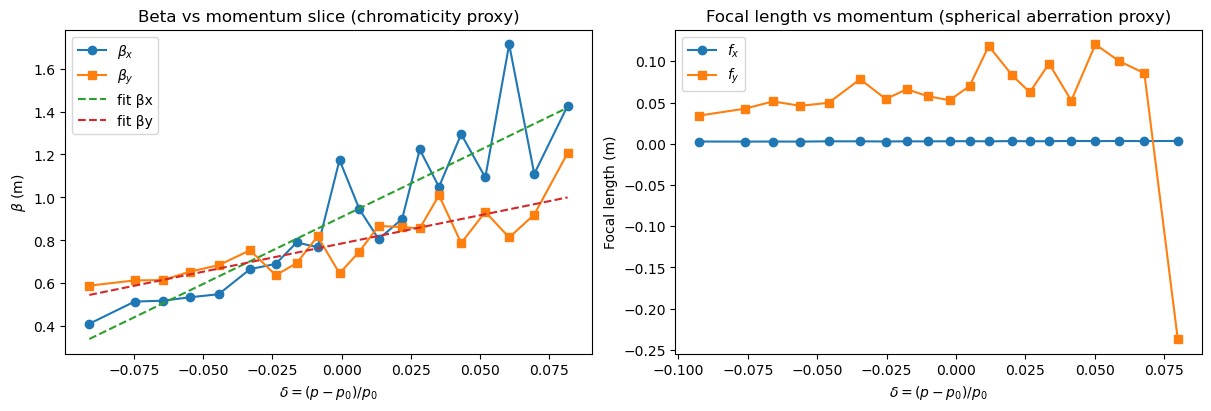

In [162]:
def tune_vs_momentum(df, n_slices=20):
    p = p_total(df)
    p_mean = np.mean(p)
    
    # slice by momentum
    p_edges = np.percentile(p, np.linspace(0, 100, n_slices+1))
    
    betas_x, betas_y, deltas = [], [], []
    for i in range(n_slices):
        mask = (p >= p_edges[i]) & (p < p_edges[i+1])
        slice_df = df[mask]
        if len(slice_df) < 50:
            continue
        x_params, y_params, _ = calc_all_params(slice_df)
        betas_x.append(x_params[1])
        betas_y.append(y_params[1])
        deltas.append((np.mean(p[mask]) - p_mean) / p_mean)
    
    return np.array(deltas), np.array(betas_x), np.array(betas_y)


def focal_length_vs_momentum(df_before, df_after, n_slices=20):
    """
    Focal length from x' = -x/f  →  f = -<x> / <x'>
    computed per momentum slice
    """
    p_before = p_total(df_before)
    p_after  = p_total(df_after)
    p_mean   = np.mean(p_before)
    
    # match particles by EventID
    df_before = df_before.set_index("EventID")
    df_after  = df_after.set_index("EventID")
    common    = df_before.index.intersection(df_after.index)
    db = df_before.loc[common]
    da = df_after.loc[common]
    
    p_edges = np.percentile(p_total(db), np.linspace(0, 100, n_slices+1))
    p_vals  = p_total(db)
    
    focal_x, focal_y, deltas = [], [], []
    for i in range(n_slices):
        mask = (p_vals >= p_edges[i]) & (p_vals < p_edges[i+1])
        if mask.sum() < 50:
            continue
        
        x_in  = db["x"][mask].values
        xp_in = (db["Px"] / p_total(db))[mask].values
        x_out = da["x"][mask].values
        xp_out = (da["Px"] / p_total(da))[mask].values
        
        y_in  = db["y"][mask].values
        yp_in = (db["Py"] / p_total(db))[mask].values
        yp_out = (da["Py"] / p_total(da))[mask].values
        
        # f = -<x_in> / <delta_xp>  where delta_xp = xp_out - xp_in
        delta_xp = xp_out - xp_in
        delta_yp = yp_out - yp_in

        # robust linear fit: delta_xp = (-1/f) * x_in
        if len(x_in) > 10:
            coef = np.polyfit(x_in, delta_xp, 1)   # slope, intercept
            slope = coef[0]
            fx = -1 / slope if np.abs(slope) > 1e-6 else np.nan
        else:
            fx = np.nan
        if len(y_in) > 10:
            coef_y = np.polyfit(y_in, delta_yp, 1)
            slope_y = coef_y[0]
            fy = -1 / slope_y if np.abs(slope_y) > 1e-6 else np.nan
        else:
            fy = np.nan
        
        focal_x.append(fx)
        focal_y.append(fy)
        deltas.append((np.mean(p_vals[mask]) - p_mean) / p_mean)
    
    return np.array(deltas), np.array(focal_x), np.array(focal_y)


# --- plot ---
# for tune shift you need df after the QQ
deltas, bx, by = tune_vs_momentum(df_opt_q)

# Linear fit: beta vs momentum (chromaticity proxy)
coef_x = np.polyfit(deltas, bx, 1)
coef_y = np.polyfit(deltas, by, 1)

print("Chromaticity proxy (slope of beta vs delta):")
print(f"dβx/dδ ≈ {coef_x[0]:.4f}")
print(f"dβy/dδ ≈ {coef_y[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

axes[0].plot(deltas, bx, "o-", label=r"$\beta_x$")
axes[0].plot(deltas, by, "s-", label=r"$\beta_y$")
axes[0].set_xlabel(r"$\delta = (p - p_0)/p_0$")
axes[0].set_ylabel(r"$\beta$ (m)")
axes[0].set_title("Beta vs momentum slice (chromaticity proxy)")
coef2_x = np.polyfit(deltas, bx, 2)
print("Quadratic term βx:", coef2_x[0])
# fitted lines
delta_fit = np.linspace(min(deltas), max(deltas), 100)

axes[0].plot(delta_fit, np.polyval(coef_x, delta_fit), "--", label="fit βx")
axes[0].plot(delta_fit, np.polyval(coef_y, delta_fit), "--", label="fit βy")

axes[0].legend()
# for focal length you need df before AND after the QQ
deltas_f, fx, fy = focal_length_vs_momentum(post_w1, df_opt_q)

axes[1].plot(deltas_f, fx/1000, "o-", label=r"$f_x$")  # mm to m
axes[1].plot(deltas_f, fy/1000, "s-", label=r"$f_y$")
axes[1].set_xlabel(r"$\delta = (p - p_0)/p_0$")
axes[1].set_ylabel("Focal length (m)")
axes[1].set_title("Focal length vs momentum (spherical aberration proxy)")
axes[1].legend()

plt.show()

In [131]:
x_params_q, y_params_q, z_emit_q = calc_all_params(df_opt_q)
print("Dx, Dxp =", x_params_q[4], x_params_q[5])
b_dict = {"Beta_x" : x_params_q[1], "Beta_y" : y_params_q[1]}
print(b_dict)
print("E_x = ", x_params_q[0], "E_y = ", y_params_q[0])
with open("particles_after_q2upt.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print("Transmission = ", trans_percent)

Dx, Dxp = 0.040290971537618 -0.8044143235153144
{'Beta_x': np.float64(0.4030870963582123), 'Beta_y': np.float64(0.7526127684290701)}
E_x =  0.7401946826026065 E_y =  0.1620752022067139
1900
Transmission =  95.0


In [125]:
if os.path.exists("particles_after_q2upt.txt"):
    os.remove("particles_after_q2upt.txt")
convertZ("particles_after_q2.txt", "particles_after_q2upt.txt", set_to=0.0)
df_opt_q_zero = read_trackfile("particles_after_q2upt.txt")

Updated file saved as 'particles_after_q2upt.txt'


In [182]:
# Radius of S1 needs to be
radius_s = max(
    np.percentile(np.abs(df_opt_q["x"]), 99.9),
    np.percentile(np.abs(df_opt_q["y"]), 99.9)
    ) * 10.0
print("So the sextupole radius: " + str(radius_s) + " mm")

So the sextupole radius: 427.82500800000025 mm


In [199]:
def run_sextupole(df, S1_strength, S1_z, S1_length, dp_fraction=0, S1_radius=radius_s, thickness=5):
    """
    Runs G4BL with two sequential quadrupoles.
    """
    Drift1_width=2*S1_radius
    Drift1_height=2*S1_radius
    # Q1_z : f"{L_centerline + (Q1_length / 2):.12f}",
    params = {
    "S1_z": f"{S1_z + (S1_length / 2):.12f}",
    "S1_length": f"{S1_length:.12f}",
    "S1_strength": f"{S1_strength:.12f}",
    "S1_radius": f"{S1_radius:.12f}",
    "S1_end": f"{S1_z + S1_length:.12f}",
    "thickness": f"{thickness}"
    }

    print("PARAMS PASSED TO TEMPLATE:")
    for k, v in params.items():
        print(k, "=", v)
    write_input_from_template("G4_FinalCooling_dispsup_S.g4bl", params, "G4_FinalCooling_dispsup_S_run.g4bl")
    
    
    df_mod = df.copy()

    if dp_fraction != 0.0:
        print(f"Applying dp/p = {dp_fraction}")

        df_mod["Pz"] *= (1.0 + dp_fraction)

        if "Px" in df_mod and "Py" in df_mod:
            df_mod["Px"] *= (1.0 + dp_fraction)
            df_mod["Py"] *= (1.0 + dp_fraction)
    # Run this file
    res = run_g4beam(df_mod, "G4_FinalCooling_dispsup_S_run.g4bl")

    if res is None or len(res) < 10:
        print("G4BL run failed or empty. Check template and parameters.")
        return None
    return res

In [200]:
def optimize_s(x, df, beta_x_ref, beta_y_ref, w_disp=1000, w_beta=1000.0, w_chrom=500000.0):
    s1_strength, s1_z, s1_length = x
    print("\nTRYING x =", x)

    try:
        result = run_sextupole(df, s1_strength, s1_z, s1_length)
        N0 = 2000
        Ns = len(result)
    except Exception as e:
        print("EXCEPTION in run_sextupole:", e)
        return 1e6

    if Ns / N0 < 0.95:
        print(f"Survival too low: {Ns / N0}, returning penalty")
        return 1e7 + 1e6 * (0.95 - Ns / N0)

    # Compute optics parameters
    try:
        x_params, y_params, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5

    Dx, Dxp = x_params[4], x_params[5]
    beta_x, beta_y = x_params[1], y_params[1]

    # --- Dispersion and beta penalties
    eps = 1e-4
    disp_penalty =  (np.abs(Dx) / 1e-4)**2 + (np.abs(Dxp) / 1e-2)**2
    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 + ((beta_y - beta_y_ref)/beta_y_ref)**2

    # --- Chromaticity penalty
    # Approximate by tracking particles at ±dp/p
    dp = 0.01  # 1% momentum offset
    result_plus = run_sextupole(df, s1_strength, s1_z, s1_length, dp_fraction=+dp)
    result_minus = run_sextupole(df, s1_strength, s1_z, s1_length, dp_fraction=-dp)
    x_params_plus, y_params_plus, _ = calc_all_params(result_plus)
    x_params_minus, y_params_minus, _ = calc_all_params(result_minus)

    xi_x = (x_params_plus[1] - x_params_minus[1]) / (2 * dp * beta_x_ref)
    xi_y = (y_params_plus[1] - y_params_minus[1]) / (2 * dp * beta_y_ref)
    chrom_penalty = xi_x**2 + xi_y**2

    # --- Combine penalties (log-scaled)
    optics_loss = w_beta * np.log(beta_penalty**2 + eps)
    disp_loss = w_disp * np.log(disp_penalty + eps)
    chrom_loss = w_chrom * np.log(chrom_penalty + eps)

    val = optics_loss + disp_loss + chrom_loss

    print(f"OBJECTIVE={val:.6f}, Dx={Dx:.6f}, Dxp={Dxp:.6f}, beta_penalty={beta_penalty:.6f}, chrom_penalty={chrom_penalty:.6f}")
    return val

In [201]:
B_pole_max = 5.0
SstrBound = B_pole_max / (radius_s*1e-3)**2
print(f"Max strength bound for sextupoles : ({-SstrBound}, {SstrBound}) ")

Max strength bound for sextupoles : (-27.317293579099083, 27.317293579099083) 


In [202]:
x0 = [10, 100, 200]# [ -9.00758863, 11.56562394, 19.697143, L_centerline*2] #[-9.00758863, 11.56562394,  40.41906277, L_centerline] # [ -9.00758863, 11.56562394, 19.697143, L_centerline]
# [-61.97363495  69.06470063   2.02317333  25.        ] BEST transmission
# Physical bounds
bounds = np.array([
    [-SstrBound, SstrBound],      # S1_strength
    [50, 1000], #S1_Z
    [100, 2000] #S1_length
])

res = scipy.optimize.minimize(
    optimize_s, x0,
    args=(df_opt_q_zero, x_params_q[1], y_params_q[1]),
    method="Nelder-Mead", bounds=bounds,
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500})


TRYING x = [ 10. 100. 200.]
PARAMS PASSED TO TEMPLATE:
S1_z = 200.000000000000
S1_length = 200.000000000000
S1_strength = 10.000000000000
S1_radius = 427.825008000000
S1_end = 300.000000000000
thickness = 5
Survival too low: 0.9245, returning penalty

TRYING x = [ 10.5 100.  200. ]
PARAMS PASSED TO TEMPLATE:
S1_z = 200.000000000000
S1_length = 200.000000000000
S1_strength = 10.500000000000
S1_radius = 427.825008000000
S1_end = 300.000000000000
thickness = 5
Survival too low: 0.924, returning penalty

TRYING x = [ 10. 105. 200.]
PARAMS PASSED TO TEMPLATE:
S1_z = 205.000000000000
S1_length = 200.000000000000
S1_strength = 10.000000000000
S1_radius = 427.825008000000
S1_end = 305.000000000000
thickness = 5
Survival too low: 0.9225, returning penalty

TRYING x = [ 10. 100. 210.]
PARAMS PASSED TO TEMPLATE:
S1_z = 205.000000000000
S1_length = 210.000000000000
S1_strength = 10.000000000000
S1_radius = 427.825008000000
S1_end = 310.000000000000
thickness = 5
Survival too low: 0.9215, returnin

In [ ]:
df_opt_s = run_sextupole(df_opt_q_zero, res.x[0], res.x[1], res.x[2])

PARAMS PASSED TO TEMPLATE:
S1_z = 100.000000000000
S1_length = 100.000000000000
S1_strength = 0.003564408879
S1_radius = 427.825008000000
S1_end = 150.000000000000
thickness = 5


In [205]:
x_params_s, y_params_s, z_emit_s = calc_all_params(df_opt_s)
print("Dx, Dxp =", x_params_s[4], y_params_s[5])
b_dict = {"Beta_x" : x_params_s[1], "Beta_y" : y_params_s[1]}
print(b_dict)
print("E_x = ", x_params_s[0], "E_y = ", y_params_s[0])
with open("particles_after_q2upt.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print("Transmission = ", trans_percent)

Dx, Dxp = -0.11064628209209318 0.08272867975657003
{'Beta_x': np.float64(0.4988341040603959), 'Beta_y': np.float64(2.5922505078913334)}
E_x =  3.4073284661491945 E_y =  0.4680501637103772
1900
Transmission =  95.0


Chromaticity proxy (slope of beta vs delta):
dβx/dδ ≈ 0.1619
dβy/dδ ≈ 13.5526
Quadratic term βx: -7.305532243061081


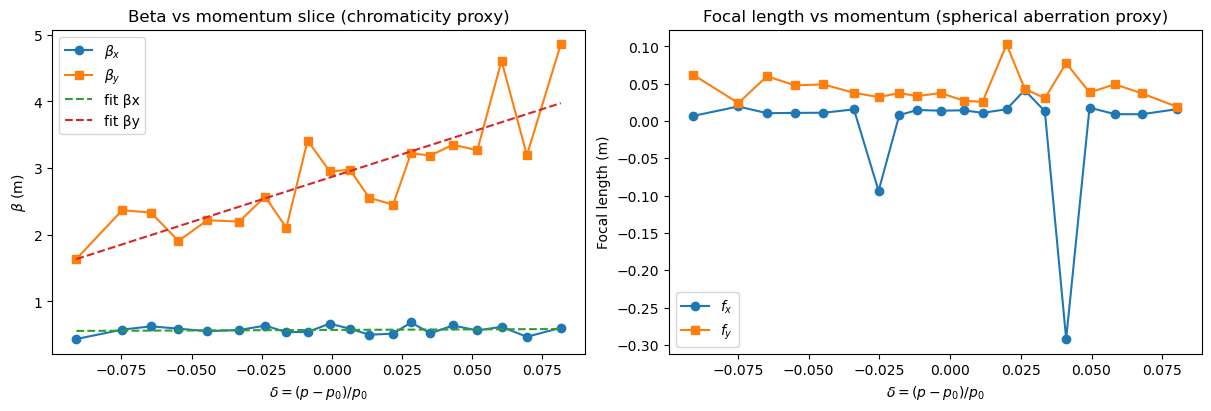

In [207]:
def tune_vs_momentum(df, n_slices=20):
    p = p_total(df)
    p_mean = np.mean(p)
    
    # slice by momentum
    p_edges = np.percentile(p, np.linspace(0, 100, n_slices+1))
    
    betas_x, betas_y, deltas = [], [], []
    for i in range(n_slices):
        mask = (p >= p_edges[i]) & (p < p_edges[i+1])
        slice_df = df[mask]
        if len(slice_df) < 50:
            continue
        x_params, y_params, _ = calc_all_params(slice_df)
        betas_x.append(x_params[1])
        betas_y.append(y_params[1])
        deltas.append((np.mean(p[mask]) - p_mean) / p_mean)
    
    return np.array(deltas), np.array(betas_x), np.array(betas_y)


def focal_length_vs_momentum(df_before, df_after, n_slices=20):
    """
    Focal length from x' = -x/f  →  f = -<x> / <x'>
    computed per momentum slice
    """
    p_before = p_total(df_before)
    p_after  = p_total(df_after)
    p_mean   = np.mean(p_before)
    
    # match particles by EventID
    df_before = df_before.set_index("EventID")
    df_after  = df_after.set_index("EventID")
    common    = df_before.index.intersection(df_after.index)
    db = df_before.loc[common]
    da = df_after.loc[common]
    
    p_edges = np.percentile(p_total(db), np.linspace(0, 100, n_slices+1))
    p_vals  = p_total(db)
    
    focal_x, focal_y, deltas = [], [], []
    for i in range(n_slices):
        mask = (p_vals >= p_edges[i]) & (p_vals < p_edges[i+1])
        if mask.sum() < 50:
            continue
        
        x_in  = db["x"][mask].values
        xp_in = (db["Px"] / p_total(db))[mask].values
        x_out = da["x"][mask].values
        xp_out = (da["Px"] / p_total(da))[mask].values
        
        y_in  = db["y"][mask].values
        yp_in = (db["Py"] / p_total(db))[mask].values
        yp_out = (da["Py"] / p_total(da))[mask].values
        
        # f = -<x_in> / <delta_xp>  where delta_xp = xp_out - xp_in
        delta_xp = xp_out - xp_in
        delta_yp = yp_out - yp_in

        # robust linear fit: delta_xp = (-1/f) * x_in
        if len(x_in) > 10:
            coef = np.polyfit(x_in, delta_xp, 1)   # slope, intercept
            slope = coef[0]
            fx = -1 / slope if np.abs(slope) > 1e-6 else np.nan
        else:
            fx = np.nan
        if len(y_in) > 10:
            coef_y = np.polyfit(y_in, delta_yp, 1)
            slope_y = coef_y[0]
            fy = -1 / slope_y if np.abs(slope_y) > 1e-6 else np.nan
        else:
            fy = np.nan
        
        focal_x.append(fx)
        focal_y.append(fy)
        deltas.append((np.mean(p_vals[mask]) - p_mean) / p_mean)
    
    return np.array(deltas), np.array(focal_x), np.array(focal_y)


# --- plot ---
# for tune shift you need df after the QQ
deltas, bx, by = tune_vs_momentum(df_opt_s)

# Linear fit: beta vs momentum (chromaticity proxy)
coef_x = np.polyfit(deltas, bx, 1)
coef_y = np.polyfit(deltas, by, 1)

print("Chromaticity proxy (slope of beta vs delta):")
print(f"dβx/dδ ≈ {coef_x[0]:.4f}")
print(f"dβy/dδ ≈ {coef_y[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

axes[0].plot(deltas, bx, "o-", label=r"$\beta_x$")
axes[0].plot(deltas, by, "s-", label=r"$\beta_y$")
axes[0].set_xlabel(r"$\delta = (p - p_0)/p_0$")
axes[0].set_ylabel(r"$\beta$ (m)")
axes[0].set_title("Beta vs momentum slice (chromaticity proxy)")
coef2_x = np.polyfit(deltas, bx, 2)
print("Quadratic term βx:", coef2_x[0])
# fitted lines
delta_fit = np.linspace(min(deltas), max(deltas), 100)

axes[0].plot(delta_fit, np.polyval(coef_x, delta_fit), "--", label="fit βx")
axes[0].plot(delta_fit, np.polyval(coef_y, delta_fit), "--", label="fit βy")

axes[0].legend()
# for focal length you need df before AND after the QQ
deltas_f, fx, fy = focal_length_vs_momentum(post_w1, df_opt_s)

axes[1].plot(deltas_f, fx/1000, "o-", label=r"$f_x$")  # mm to m
axes[1].plot(deltas_f, fy/1000, "s-", label=r"$f_y$")
axes[1].set_xlabel(r"$\delta = (p - p_0)/p_0$")
axes[1].set_ylabel("Focal length (m)")
axes[1].set_title("Focal length vs momentum (spherical aberration proxy)")
axes[1].legend()

plt.show()

In [208]:
def check_dipole_clearance(df, B_val, B_radius, B_angle, B_thickness):
    """
    Check which particles clear the dipole aperture based on their Larmor radius
    and deflection geometry.

    Parameters:
      df : pandas.DataFrame with columns ['Px','Py','Pz'] in MeV/c
      B_val : magnetic field (Tesla)
      dipole_length_mm : dipole magnet effective length (mm)
      dipole_halfwidth_mm : half-width of dipole aperture (mm)

    Returns:
      surviving_mask : boolean array, True if particle clears aperture
      r_L_mm : array of Larmor radii (mm)
      delta_r_mm : array of deflections (mm)
    """
    dipole_length_mm = 2 * B_radius * math.sin(B_angle * math.pi/360)
    dipole_halfwidth_mm = B_thickness
    # constants
    e = 1.602176634e-19  # C
    c = 2.99792458e8     # m/s

    # convert MeV/c to SI (kg·m/s)
    mom_perp = np.sqrt(df["Px"]**2 + df["Pz"]**2) * 1e6 * e / c  # B assumed along y

    # Larmor radius [m]
    r_L = mom_perp / (e * np.abs(B_val))

    # convert to mm
    r_L_mm = r_L * 1e3
    s_mm = dipole_length_mm

    # deflection Δr = r * (1 - cos(φ)), φ = s / r
    phi = s_mm / r_L_mm
    delta_r_mm = r_L_mm * (1 - np.cos(phi))

    # check if deflection < half-width
    surviving_mask = delta_r_mm < dipole_halfwidth_mm
    

    return surviving_mask, r_L_mm, delta_r_mm

In [234]:
write_trackfile(df_opt_s, "particles_after_s.txt")
convertZ("particles_after_s.txt", "particles_after_supt.txt")
df_opt_s_zero = read_trackfile("particles_after_supt.txt")

Updated file saved as 'particles_after_supt.txt'


In [235]:
# Height and Width of B field
size_b = max(
    np.percentile(np.abs(df_opt_s["x"]), 99.9),
    np.percentile(np.abs(df_opt_s["y"]), 99.9)
    ) * 10.0
print("So the B radius: " + str(size_b) + " mm")

So the B radius: 2009.4671400000127 mm


In [236]:
def run_dipole(df, B_field, B_angle, B_radius, B_z, B_thickness=50, B_height=100):
    if os.path.exists("field_cellB.dat"):
        os.remove("field_cellB.dat")
    """Run dipole simulation with given parameters."""
    params = {
        "B1_field": B_field,
        "B1_angle": B_angle,
        "B1_radius": B_radius,
        "B1_z": B_z,
        "B1_z_end": B_z + 2 * (B_radius * B_angle * math.pi/360)+0.1,
        "B1_x_end": B_z - B_thickness * math.sin(B_angle * math.pi/360),
        "B1_thickness": B_thickness,
        "B1_height": B_height
    }
    write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", params, "G4_FinalCooling_dispsup_B_run.g4bl")
    # Run G4Beamline
    df_out = run_g4beam(df, "G4_FinalCooling_dispsup_B_run.g4bl")

    return df_out

In [237]:
def optimize_dipole(x, df_in, beta_x_ref, beta_y_ref, 
                    w_disp=10000.0, w_beta=1.0, 
                    D_tol=1e-4, survival_threshold=0.95):
    """
    Optimize dipole parameters using G4Beamline simulations.

    Parameters
    ----------
    x : array-like
        Dipole parameters: [B_field, B_angle_deg, B_radius]
    df_in : pandas.DataFrame
        Input particle distribution
    beta_x_ref, beta_y_ref : float
        Target beta functions
    w_disp, w_beta : float
        Weights for cost function
    survival_threshold : float
        Minimum fraction of particles that must survive

    Returns
    -------
    float
        Objective function value (smaller is better)
    """
    # Unpack parameters
    B_field, B_angle, B_radius, B_z = x
    B_thickness = 50.0
    B_height = 100.0

    # Run dipole simulation
    result = run_dipole(df_in, B_field, B_angle, B_radius, B_z)
    if result is None or len(result) == 0:
        # no particles survived, penalize heavily
        return 1e6

    mask, r_L_mm, delta_r_mm = check_dipole_clearance(df_in, B_field, B_angle, B_radius, B_thickness)
    mask = mask[:len(result)]  # truncate if needed
    if len(result) == 0:
        survival_frac = 0.0
    else:
        if isinstance(result, np.ndarray):
            df_survived = result[mask]
        else:
            df_survived = result[mask.values]
        survival_frac = len(df_survived) / len(df_in)
        print(f"Survival fraction: {survival_frac}")

    if survival_frac < survival_threshold:
        return 1e6 + 1e3*(survival_threshold - survival_frac)

    x_params_d, y_params_d, _ = calc_all_params(result)
    Dx   = x_params_d[4]
    Dxp  = x_params_d[5]
    beta_x = x_params_d[1]
    beta_y = y_params_d[1]

    beta_x_max = 0.9    
    beta_y_max = 0.9

    disp_penalty = 100000 * (np.abs(Dx) / 1e-4)**2 + (np.abs(Dxp) / 1e-2)**2
    beta_penalty = (max(0, beta_x - beta_x_max) / beta_x_max)**2 \
                + (max(0, beta_y - beta_y_max) / beta_y_max)**2

    val = w_disp * disp_penalty + w_beta * beta_penalty
    print(f"Objective = {val:.3f}, Survival = {survival_frac:.3f}, Dx = {Dx:.6f}, Dxp = {Dxp:.4f}, beta_x = {beta_x:.3f}, beta_y = {beta_y:.3f}")
    return val

In [240]:
start = time.time()
# Run optimization
optim_result = minimize(optimize_dipole, [1.5, 2.0, size_b, 1.0], args=(df_opt_s_zero, b_dict["Beta_x"], b_dict["Beta_y"]), method="Nelder-Mead", bounds=((-5.0, 5.0), (1.0, 10.0), (size_b, size_b*10), (0.5, 1000.0)), options=dict(fatol=1e-6))

# Get results
B_field, B_angle, B_radius, B_z = optim_result.x
print(f"Field = {B_field:.2f} T \nAngle = {B_angle:.2f} deg\nRadius = {B_radius:.1f} mm\nSpacing = {B_z:.1f} mm")
print("Time spent:", time.time()-start)

iter value
Survival fraction: 0.4831578947368421
Survival fraction: 0.48
Survival fraction: 0.46473684210526317
Survival fraction: 0.46421052631578946
Survival fraction: 0.4831578947368421
Survival fraction: 0.4694736842105263
Survival fraction: 0.4942105263157895
Survival fraction: 0.508421052631579
Survival fraction: 0.5026315789473684
Survival fraction: 0.5063157894736842
Survival fraction: 0.5189473684210526
Survival fraction: 0.5363157894736842
Survival fraction: 0.5452631578947369
Survival fraction: 0.5810526315789474
Survival fraction: 0.5605263157894737
Survival fraction: 0.5952631578947368
Survival fraction: 0.6494736842105263
Survival fraction: 0.6721052631578948
Survival fraction: 0.6778947368421052
Survival fraction: 0.6763157894736842
Survival fraction: 0.6768421052631579
Survival fraction: 0.6773684210526316
Survival fraction: 0.6773684210526316
Survival fraction: 0.6773684210526316
Survival fraction: 0.6768421052631579
Survival fraction: 0.6778947368421052
Survival fract

In [223]:
opt_params = {
        "B1_field": optim_result.x[0],
        "B1_angle": optim_result.x[1],
        "B1_radius": optim_result.x[2],
        "B1_z": optim_result.x[3],
        "B1_z_end": optim_result.x[3] + 2 * (optim_result.x[2] * optim_result.x[1] * math.pi/360)+0.1,
        "B1_x_end": optim_result.x[3] - 50 * math.sin(optim_result.x[1] * math.pi/360),
        "B1_thickness": 50,
        "B1_height": 100,
    }
if os.path.exists("field_cellB.dat"):
    os.remove("field_cellB.dat")
write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", opt_params, "G4_FinalCooling_dispsup_B_opt2.g4bl")
df_dip = run_g4beam(df_opt_q, "G4_FinalCooling_dispsup_B_opt2.g4bl")

In [224]:
write_trackfile(df_dip, "particles_after_b.txt")

In [225]:
if os.path.exists("particles_after_bupt.txt"):
    os.remove("particles_after_bupt.txt")
convertZ("particles_after_b.txt",  "particles_after_bupt.txt")

x_params_dip, y_params_dip, z_emit_dip = calc_all_params(df_dip)
D_dict_dip = {"D_x": x_params_dip[4], "D'_x": x_params_dip[5], "D_y": y_params_dip[4], "D'_y": y_params_dip[5]}
b_dict_dip = {"Beta_x": x_params_dip[1], "Beta_y": y_params_dip[1]}
print(D_dict_dip, r"Epsilon_z: "+str(z_emit_dip), b_dict_dip)

Updated file saved as 'particles_after_bupt.txt'
{'D_x': np.float64(0.03546242111619123), "D'_x": np.float64(-0.7831057854296529), 'D_y': np.float64(0.00638507392452247), "D'_y": np.float64(0.08272793489354192)} Epsilon_z: 7.3454501503969825 {'Beta_x': np.float64(0.2975579842054478), 'Beta_y': np.float64(0.8446763316740044)}


In [147]:
df_dip_zero = read_trackfile("particles_after_firstwedgeupt.txt")

In [ ]:
# Sigma cut for phase space -- contribution for the cooling is just 1sigma -- dispersion calculation, useful particles can be in 1 sigma, makes the statement a bit more clear, how do we treat the tail
# 3 sigma cut, 5 sigma cut, dispersion include non-linear tail effect. Increase actual dispersion. In the future we take into account this tail transmission 

In [155]:
print_all_params(remove_dispersion(post_w1))

-----------------------------
Twiss parameters for X
emit  = 0.03310087031121253 mm
beta  = 0.042970980606148866 m
gamma = 243.11424826145335 1/m
alpha = -3.073574083558321
D     = 1.6064378521460772e-05 m
D'    = 0.0004377299996538175

Twiss parameters for Y
emit  = 0.14774364355638603 mm
beta  = 0.025456495464102554 m
gamma = 56.09787832599641 1/m
alpha = -0.6542594173196935
D     = -2.376858971420473e-06 m
D'    = 2.3781715043548184e-05

Z-emittance:  3.6873550775478723 mm
Z std: 143.04401071705382 mm
p std: 4.2374835174424055 MeV/c
Mean momentum: 88.4100226266221 MeV/c
-----------------------------


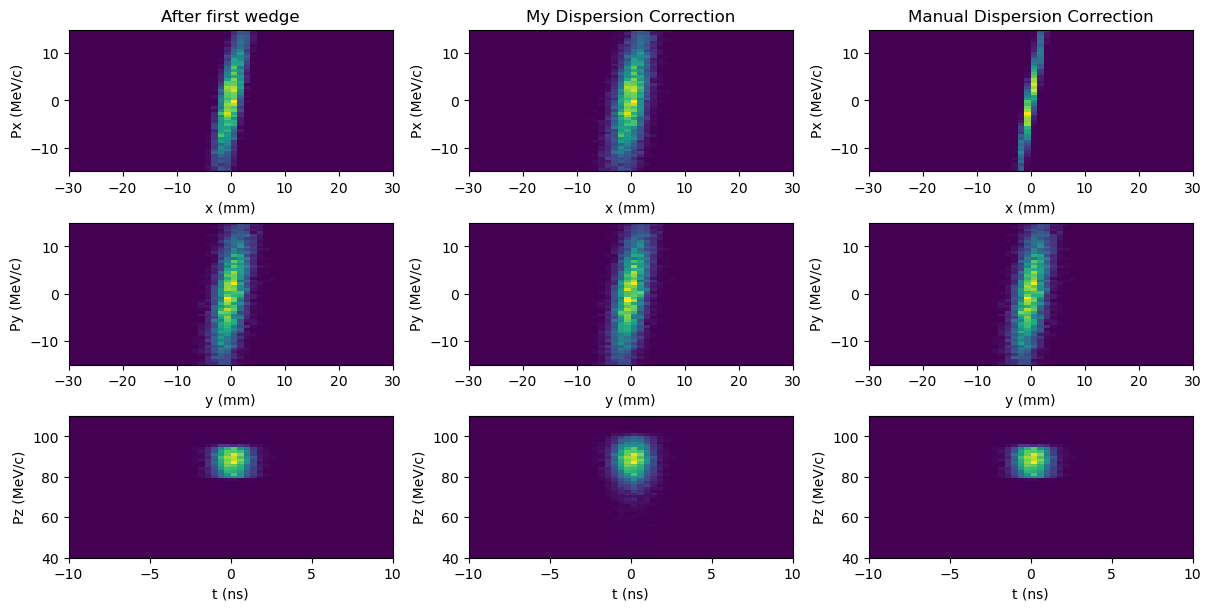

In [148]:
# a more reasonable size
PLOT_TARGETS = [post_w1, df_dip_zero, remove_dispersion(post_w1)]
PLOT_TITLES = ["After first wedge", "My Dispersion Correction", "Manual Dispersion Correction"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-30, 30], [-15, 15]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(12, 6)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

In [36]:
df_dip_zero = read_trackfile("particles_after_bupt.txt")

In [37]:
with open("particles_after_bupt.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

1201
60.05


# Phase rotation

The following are taken as constants, as they are primarily constrained by technical limitations. The optimal RF gradient is heavily dependent on both of these.
- **Drift length**: Longer drift length will give better results
- **RF frequency**: Lower frequency will usually give better results. There's an optimal point, but I believe it's lower than practical

We then optimize the RF phase, cavity length, and gradient

In [44]:
print_all_params(remove_dispersion(post_w1))
print_all_params(df_dip)

-----------------------------
Twiss parameters for X
emit  = 0.034396103274171155 mm
beta  = 0.04257556616703184 m
gamma = 241.01937127082948 1/m
alpha = -3.0432772119998557
D     = 1.58026235359332e-06 m
D'    = -0.0007919660109643029

Twiss parameters for Y
emit  = 0.14817468688127206 mm
beta  = 0.025471408941359026 m
gamma = 56.2199682464752 1/m
alpha = -0.657268439738429
D     = -1.4910339583670178e-06 m
D'    = 5.1880689224131575e-05

Z-emittance:  4.594360876099441 mm
Z std: 143.09907989317048 mm
p std: 5.233994738836391 MeV/c
Mean momentum: 88.31077326576842 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.19021336231471156 mm
beta  = 0.0872242293268795 m
gamma = 117.27236488217102 1/m
alpha = 3.037925550139103
D     = 7.531900288367735e-07 m
D'    = -0.22327535719275626

Twiss parameters for Y
emit  = 0.15071780943566737 mm
beta  = 1.5725397318608847 m
gamma = 115.72994273038721 1/m
alpha = -13.453249908833131
D     = 0.01191518

In [38]:
no_transverse = remove_transverse(df_dip)

# Reverse transverse momentums in saved copy
reverse_transverse = df_dip.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1

In [39]:
drift_length = 16000
rf_freq = 0.025

start = time.time()
# Function to optimize
def func(x):
    rf_phase, rf_length, rf_grad = x
    drift_to_start = drift_length-rf_length/2
    post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
    post_cavity = run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))
    pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
    return np.std(p_total(cut_pz(pre_w2)))

# Run optimization
optim_result = minimize(func, [0, 4700, 7], method="Nelder-Mead", bounds=((-90, 90), (2000, 6000), (1, 10)), options=dict(fatol=1e-6))

# Get results
rf_phase, rf_length, rf_grad = optim_result.x
print(f"Phase = {rf_phase:.2f} deg\nLength = {rf_length:.0f} mm\nGradient = {rf_grad:.2f} MV/m\nFrequency = {rf_freq*1000:.1f} MHz")
print("Time spent:", time.time()-start)

# Runs a single case with the optimal parameters and add the transverse back in
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
post_cavity = cut_pz(recenter_t(run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad)))
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print_all_params(pre_w2)

iter value
  88 1.92307e+00
Phase = 0.00 deg
Length = 5411 mm
Gradient = 3.86 MV/m
Frequency = 25.0 MHz
Time spent: 782.623950958252
-----------------------------
Twiss parameters for X
emit  = 0.14598072205678614 mm
beta  = 0.08556667367572461 m
gamma = 115.47916286740941 1/m
alpha = -2.980128830339634
D     = 0.08500610645860975 m
D'    = 3.178027612827992

Twiss parameters for Y
emit  = 0.13763549014162255 mm
beta  = 1.5427776983354144 m
gamma = 125.18983341710843 1/m
alpha = 13.86146035070766
D     = 0.04185637221612441 m
D'    = -0.37762346282166553

Z-emittance:  3.687848012990306 mm
Z std: 653.6831163387424 mm
p std: 1.9230688596847523 MeV/c
Mean momentum: 88.06549393894143 MeV/c
-----------------------------


In [41]:
write_trackfile(pre_w2, "particles_after_driftph.txt")

In [42]:
with open("particles_after_driftph.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

1009
50.45


# Second wedge

Optimize the second wedge in the same way as the first

In [40]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w2, length, angle, vd_dist, axis=1)))[1]

# Run optimization
optim_result = minimize(func, [5.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w2_length, w2_angle = optim_result.x
print(f"Length = {w2_length:.2f} mm\nAngle = {w2_angle:.1f} deg")

# Runs a single case with the optimal parameters
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
print_all_params(post_w2)

# Do cuts at this point
post_w2_cut = cut_outliers(post_w2)
print_all_params(post_w2_cut)

iter value
  31 3.80272e-01
Length = 5.75 mm
Angle = 47.2 deg
-----------------------------
Twiss parameters for X
emit  = 0.257071542189591 mm
beta  = 0.21001387758489973 m
gamma = 76.92770921461158 1/m
alpha = -3.8930561909487253
D     = 0.0030735419642530927 m
D'    = 0.07751374124810634

Twiss parameters for Y
emit  = 0.4503958463089367 mm
beta  = 0.27220951989855124 m
gamma = 40.30646999495889 1/m
alpha = 3.1578164680888476
D     = 0.010638890017217406 m
D'    = -0.11877987638224005

Z-emittance:  43.2188496050985 mm
Z std: 619.5413459538273 mm
p std: 12.505607669367727 MeV/c
Mean momentum: 82.7937950099545 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.24517651260158135 mm
beta  = 0.21880235678196633 m
gamma = 78.97346236581187 1/m
alpha = -4.034796114907364
D     = 0.004995813601087717 m
D'    = 0.1423683243942127

Twiss parameters for Y
emit  = 0.3802720982246297 mm
beta  = 0.326703958487369 m
gamma = 47.46667389579569 1/m
alp

# Save/load result

In [33]:
# Parameter list
PARAMS = [
    "t_emit",
    "momentum",
    "beta",
    "alpha",
    "l_emit",
    "pz_std",
    "vd_dist",
    "w1_length",
    "w1_angle",
    "w2_length",
    "w2_angle",
    "drift_length",
    "rf_freq",
    "rf_phase",
    "rf_length",
    "rf_grad"
]

In [ ]:
# Show parameters
{k:globals()[k] for k in PARAMS}

In [8]:
# Input parameters
parameters = {'t_emit': 0.145,
 'momentum': 100,
 'beta': 0.03,
 'alpha': 1,
 'l_emit': 1,
 'pz_std': 1,
 'vd_dist': 24,
 'w1_length': 9.20751061747799,
 'w1_angle': 49.78231333988419,
 'w2_length': 6.724887901827298,
 'w2_angle': 42.245718529695516,
 'drift_length': 16000,
 'rf_freq': 0.025,
 'rf_phase': 0.001987066319906211,
 'rf_length': 5153.756925848655,
 'rf_grad': 4.046563465382562}
globals().update(parameters)

In [ ]:
# Save parameter set
parameters = {k:globals()[k] for k in PARAMS}
filename = "results/parameters/"+input("Enter run name to save: ")+".pkl"
with open(filename, "wb+") as file:
    pickle.dump(parameters, file)
    print("Saved to", filename)

In [ ]:
# Load parameter set
filename = "results/parameters/"+input("Enter run name to load: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    globals().update(parameters)
    print("Loaded from", filename)

In [ ]:
# View parameter set
filename = "results/parameters/"+input("Enter run name to view: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    print("Viewing", filename)
    print(parameters)

In [255]:
vd_dist=36

# Analyze single case

In [ ]:
# Tweak parameters
rf_phase += 180
rf_phase

In [ ]:
# Run best case
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=100000)
pre_w1["PDGid"] = -13
print("Running first wedge")
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
post_correct = remove_dispersion(post_w1)
reverse_transverse = post_correct.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(post_correct, drift_to_start))
no_transverse = remove_transverse(post_drift)
print("Running RF cavity")
post_cavity = cut_pz(recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))), tails=0.15)
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print("Running second wedge")
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
post_w2_cut = recenter_t(cut_outliers(post_w2))
print_all_params(post_w2_cut)
beep()

In [ ]:
# Make some phase space plots
PLOT_TARGETS = [pre_w1, post_correct, post_drift, pre_w2, remove_dispersion(post_w2_cut)]
PLOT_TITLES = ["Initial distribution", "After first wedge", "After drift", "After RF cavity and refocusing", "After second wedge"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(16, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
SAMPLE_DISTS = [pre_w1, post_correct, pre_w2, remove_dispersion(post_w2_cut)]
SAMPLE_TITLES = ["Initial distribution", "After first wedge", "After RF cavity + 10% cut", "After second wedge + 4 sigma cut"]
VARIABLE_NAMES = ["x emit (μm)", "y emit (μm)", "z-emit (mm)", "sigma-p (MeV/c)", "sigma-t (ns)", "Beam remaining"]
VARIABLE_FUNCS = [
    lambda df: emittances(df)[0]*1000,
    lambda df: emittances(df)[1]*1000,
    lambda df: emittances(df)[2],
    lambda df: np.std(p_total(df)),
    lambda df: np.std(df["t"]),
    lambda df: len(df) / len(pre_w1)
]
table = [[n] + [y(x) for y in VARIABLE_FUNCS] for n, x in zip(SAMPLE_TITLES, SAMPLE_DISTS)]
print(tabulate(
    table,
    headers=["Stage"] + VARIABLE_NAMES,
    # tablefmt="latex_raw",
    floatfmt=(None, ".1f", ".1f", ".3f", ".3f", ".3f", ".1%")
))

## Anomaly investigation

This is going insane

In [ ]:
momentum = 100
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
pre_w1["PDGid"] = -13
run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0, debug=True)

In [ ]:
momentums = list(range(50, 101, 10))
results = list() #  Yeah we're back to the old days now
for momentum in tqdm(momentums):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    pre_w1["PDGid"] = -13
    results.append(run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 3, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 12)
for momentum, x, ax in zip(momentums, results, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
pass

In [ ]:
results[0]["PDGid"]

In [ ]:
angles = [30, 40, 50, 60]
momentum = 70
results1 = list() #  Yeah we're back to the old days now
for angle in tqdm(angles):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results1.append(run_distribution(pre_w1, w1_length, angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for angle, x, ax in zip(angles, results1, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{angle} deg")
pass

In [ ]:
lengths = [3, 6, 9, 12]
momentum = 70
results2 = list() #  Yeah we're back to the old days now
for length in tqdm(lengths):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results2.append(run_distribution(pre_w1, length, w1_angle, 40, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for length, x, ax in zip(lengths, results2, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{length} mm")
pass

In [ ]:
fig, ax = plt.subplots()
ax.hist(p_total(post_w2_cut), bins=200)
select_bottom, select_top = 60.5, 62.5
ax.axvline(select_bottom, color="r", linestyle="--")
ax.axvline(select_top, color="r", linestyle="--")
anomaly = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
pre_anomaly = pre_w2.loc[anomaly["EventID"]]
post_anomaly = run_distribution(pre_anomaly, w2_length, w2_angle, vd_dist, axis=1)

In [ ]:
# Show the anomaly
PLOT_TARGETS = [pre_w2, pre_anomaly, post_w2_cut, post_anomaly]
PLOT_TITLES = ["Before (full)", "Before (anomalous)", "After (full)", "After (anomalous)"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(10, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
run_distribution(pre_w1, w2_length, w2_angle, vd_dist, axis=1, debug=True)

In [ ]:
fig, ax = plt.subplots()
ax.hist(post_w2_cut["y"], bins=200)
pass

In [ ]:
p_ranges = [(58.5+2*i, 60.5+2*i) for i in range(7)]

fig, axes = plt.subplots(ncols = 2, nrows = len(p_ranges), layout="constrained")
fig.set_size_inches(6, 3*len(p_ranges))
for i, r in enumerate(p_ranges):
    ax = axes[i][0]
    ax.hist(p_total(post_w2_cut), bins=200, range=(55, 90))
    select_bottom, select_top = r
    ax.axvline(select_bottom, color="r", linestyle="--")
    ax.axvline(select_top, color="r", linestyle="--")

    selected = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
    pre_selected = pre_w2.loc[selected["EventID"]]

    ax = axes[i][1]
    ax.hist2d(pre_selected["y"], pre_selected["Py"], bins=50, range=T_RANGES)
    ax.set_xlabel("y")
    ax.set_ylabel("Py")

## Two optimal wedges (regenerated)

In [35]:
# Range to scan
angles = np.linspace(30, 60, 20)
lengths = np.linspace(5, 11, 20)

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w2, length, angle, 24, axis=1)

results = run_scan(fun, (lengths, angles), filename="results/second_wedge_length_angle.pkl")
beep()

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w1, length, angle, 24, axis=0)

results = run_scan(fun, (lengths, angles), filename="results/first_wedge_length_angle.pkl")
beep()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(10, 4)

# First wedge

with open("results/first_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[0], results))
meshx, meshy = mesh

cax = ax1.contourf(meshx, meshy, meshz, levels=50)
ax1.set_xlabel("First wedge length (mm)")
ax1.set_ylabel("First wedge half-angle (deg)")
ax1.set_title("First wedge")
plt.colorbar(cax, ax=ax1).set_label("x-emittance (mm)")

ax1.plot(w1_length, w1_angle, 'rx')
ax1.annotate(f"{w1_length:.2f} mm, {w1_angle:.2f} deg", (w1_length, w1_angle), c="red", xytext = (-30, 10), textcoords="offset points")

# Second wedge

with open("results/second_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[1], results))
meshx, meshy = mesh

cax = ax2.contourf(meshx, meshy, meshz, levels=50)
ax2.set_xlabel("Second wedge length (mm)")
ax2.set_ylabel("Second wedge half-angle (deg)")
ax2.set_title("Second wedge")
plt.colorbar(cax, ax=ax2).set_label("y-emittance (mm)")

ax2.plot(w2_length, w2_angle, 'rx')
ax2.annotate(f"{w2_length:.2f} mm, {w2_angle:.2f} deg", (w2_length, w2_angle), c="red", xytext = (-30, 10), textcoords="offset points")

## Frequency and gradient (regenerated)

In [90]:
rf_freqs = np.linspace(0.01, 0.06, 20)
rf_grads = np.linspace(1,10,20)

In [ ]:
# get no_transverse from above

def fun(rf_grad, rf_freq):
    return recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad))

results = run_scan(fun, (rf_grads, rf_freqs), "results/rf_grad_freq_16m.pkl")

In [ ]:
with open("results/rf_grad_freq_16m.pkl", "rb") as file:
    results = pickle.load(file)
mesh = np.meshgrid(rf_grads, rf_freqs)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: np.std(cut_pz(df)["Pz"]), results))
meshx, meshy = mesh

meshy = 1000 * meshy # Scale to MHz

fig, ax = plt.subplots()
cax = ax.contourf(meshx, meshy, meshz, levels=50)
ax.set_xlabel("RF gradient (MV/m)")
ax.set_ylabel("RF frequency (MHz)")
plt.colorbar(cax).set_label("sigma-Pz (MeV/c)")

minpoint = np.unravel_index(np.argmin(meshz), meshz.shape)
ax.plot(rf_grad, rf_freq*1000, 'rx')
ax.annotate(f"{rf_grad:.2f} MV/m, {rf_freq*1000:.1f} MHz", (rf_grad, rf_freq*1000), c="red", xytext = (-30, 10), textcoords="offset points")

# Scan of optimal over pz_std

In [18]:
t_emit = 0.110  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_stds = np.linspace(0.8, 1.1, 6)
vd_dist = 24    # mm

In [ ]:
# Meta-function (containing optimization)
def metafun(pz_std):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=2e-4))

run_scan(metafun, (pz_stds,), filename="results/optimal_scan.pkl", trials=5)

In [ ]:
with open("results/optimal_scan.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]


fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"$\sigma p$ (MeV/c)")
ax1.set_ylabel("minimum x emit (mm)")

ax2.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"$\sigma p$ (MeV/c)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"$\sigma p$ (MeV/c)")
ax3.set_ylabel("optimal half-angle (deg)")

In [ ]:
calc_quantity(optim_fun, results)

In [ ]:
1e-5

In [ ]:
calc_quantity(optim_fun, results)[(0.8,)][1] / 1e-4